# Joint Optimization: Feature Selection & Hyperparameter Tuning (Hybrid PSO-GA)

This notebook implements the final, most advanced stage of the project: **Joint Optimization**.
Instead of optimizing features and parameters separately, we optimize them simultaneously using a Hybrid PSO-GA.

**Rationale:**
A subset of features that performs well with a default Decision Tree might perform poorly with a deeply constrained tree, and vice versa. Joint optimization searches for the **Global Optimum** in the combined space of `{Features} x {Hyperparameters}`.

**Particle Representation:**
Each particle is a vector divided into two segments:
1.  **Feature Segment**: Binary values representing selected features.
2.  **Parameter Segment**: Continuous values mapped to hyperparameters (max_depth, min_samples_split, criterion).

In [ ]:
import os
import pandas as pd 
import numpy as np
import time
import json
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings("ignore")

In [9]:
# Load Data
df = pd.read_csv('processed_cicids2017.csv')
df.dropna(inplace=True)

X = df.drop(columns=['Label'])
y = df['Label']
feature_names = X.columns.tolist()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total Features: {X.shape[1]}")
print(f"Training Samples: {X_train.shape[0]}")

Total Features: 77
Training Samples: 201663


In [10]:
class Joint_PSOGA_Optimizer:
    def __init__(self, X_train, y_train, n_particles=20, n_iterations=10, n_jobs=4, alpha=0.005):
        self.X_train = X_train
        self.y_train = y_train
        self.n_particles = n_particles
        self.n_iterations = n_iterations
        self.n_jobs = n_jobs
        self.alpha = alpha  # Weight for feature reduction
        
        # Dimensions
        self.n_features = X_train.shape[1]
        self.n_params = 3 # max_depth, min_samples_split, criterion
        self.total_dim = self.n_features + self.n_params
        
        # PSO Params
        self.w = 0.729    # Inertia weight
        self.c1 = 1.49445 # Cognitive (Personal)
        self.c2 = 1.49445 # Social (Global)
        self.v_max = 0.2  # Velocity clamping
        self.mutation_rate = 0.05 
        
        # Split Valid for internal fitness
        self.X_sub, self.X_val, self.y_sub, self.y_val = train_test_split(
            self.X_train, self.y_train, test_size=0.2, random_state=42, stratify=self.y_train
        )
        
        # Initialize Population (Continuous [0, 1])
        self.positions = np.random.uniform(0, 1, size=(self.n_particles, self.total_dim))
        self.velocities = np.random.uniform(-self.v_max, self.v_max, size=(self.n_particles, self.total_dim))
        
        # Best tracking
        self.pbest_pos = self.positions.copy()
        self.pbest_scores = np.full(self.n_particles, -1.0)
        
        self.gbest_pos = None
        self.gbest_score = -1.0
        
        self.history = {'iteration': [], 'accuracy': [], 'features': [], 'fitness': []}
        self.training_time = 0
        self.pbar = None

    def decode_particle(self, particle):
        """
        Decodes the continuous particle vector into:
        1. Feature Mask (Binary)
        2. Hyperparameters (Discrete/Category)
        """
        # Segment A: Features (First n_features dimensions)
        feature_vals = particle[:self.n_features]
        # Threshold at 0.5 to activate feature
        selected_indices = np.where(feature_vals > 0.5)[0]
        
        # Segment B: Parameters (Last 3 dimensions)
        param_vals = particle[self.n_features:]
        
        # Param 1: max_depth [0,1] -> Int [1, 30]
        p0 = np.clip(param_vals[0], 0, 0.9999)
        max_depth = 1 + int(p0 * 29)
        
        # Param 2: min_samples_split [0,1] -> Int [2, 20]
        p1 = np.clip(param_vals[1], 0, 0.9999)
        min_split = 2 + int(p1 * 18)
        
        # Param 3: criterion [0,1] -> {0: gini, 1: entropy}
        p2 = np.clip(param_vals[2], 0, 0.9999)
        criterion = 'entropy' if p2 > 0.5 else 'gini'
        
        return selected_indices, {'max_depth': max_depth, 'min_samples_split': min_split, 'criterion': criterion}

    def calculate_fitness(self, particle):
        selected_indices, params = self.decode_particle(particle)
        
        # Valid solution check: Must select at least 1 feature
        if len(selected_indices) == 0:
            return 0.0
            
        X_sub_sel = self.X_sub[:, selected_indices]
        X_val_sel = self.X_val[:, selected_indices]
        
        # Train with decoded parameters
        clf = DecisionTreeClassifier(
            max_depth=params['max_depth'],
            min_samples_split=params['min_samples_split'],
            criterion=params['criterion'],
            random_state=42
        )
        clf.fit(X_sub_sel, self.y_sub)
        pred = clf.predict(X_val_sel)
        
        acc = accuracy_score(self.y_val, pred)
        
        # Multi-objective Fitness: Maximize Acc, Minimize Features
        # Fitness = Acc + alpha * (1 - (selected / total))
        # This gives a small boost to simpler models with same accuracy
        feat_ratio = len(selected_indices) / self.n_features
        fitness = acc + self.alpha * (1 - feat_ratio)
        
        return fitness

    def _evaluate_batch(self, population):
        # Threading backend is crucial for Windows + Jupyter environment
        scores = Parallel(n_jobs=self.n_jobs, backend="threading")(
            delayed(self.calculate_fitness)(ind) for ind in population
        )
        return np.array(scores)

    def run(self):
        print(f"Starting Joint Optimization with {self.n_particles} particles...")
        start_time = time.time()
        
        # Initial Eval
        scores = self._evaluate_batch(self.positions)
        self.pbest_scores = scores.copy()
        
        best_idx = np.argmax(scores)
        self.gbest_pos = self.positions[best_idx].copy()
        self.gbest_score = scores[best_idx]
        
        self.pbar = tqdm(total=self.n_iterations)
        
        for iteration in range(self.n_iterations):
            # --- PSO Update ---
            for i in range(self.n_particles):
                r1, r2 = np.random.rand(), np.random.rand()
                
                # Velocity Update
                self.velocities[i] = (self.w * self.velocities[i] +
                                      self.c1 * r1 * (self.pbest_pos[i] - self.positions[i]) +
                                      self.c2 * r2 * (self.gbest_pos - self.positions[i]))
                
                # Velocity Clamping (Crucial for stability)
                self.velocities[i] = np.clip(self.velocities[i], -self.v_max, self.v_max)
                
                # Position Update
                self.positions[i] = self.positions[i] + self.velocities[i]
                self.positions[i] = np.clip(self.positions[i], 0, 1)

            # --- GA Hybrid Mutation (Probalistic) ---
            # Instead of replacing worst, we mutate a random subset of the population
            # Best practice: Don't mutate the Global Best
            
            non_best_indices = [idx for idx in range(self.n_particles) if np.array_equal(self.positions[idx], self.gbest_pos) == False]
            if len(non_best_indices) > 0:
                # Select 10-20% to mutate
                n_mutants = max(1, int(len(non_best_indices) * 0.2))
                mutant_indices = np.random.choice(non_best_indices, n_mutants, replace=False)
                
                for idx in mutant_indices:
                    # Gene-wise mutation
                    mask = np.random.rand(self.total_dim) < self.mutation_rate
                    # Assign new random values to mutated genes
                    self.positions[idx][mask] = np.random.rand(np.sum(mask))

            # Evaluate
            current_scores = self._evaluate_batch(self.positions)
            
            # Update Bests
            for i in range(self.n_particles):
                if current_scores[i] > self.pbest_scores[i]:
                    self.pbest_scores[i] = current_scores[i]
                    self.pbest_pos[i] = self.positions[i].copy()
                
                if current_scores[i] > self.gbest_score:
                    self.gbest_score = current_scores[i]
                    self.gbest_pos = self.positions[i].copy()
            
            # --- History Tracking ---
            # Extract Accuracy and Feature Count from Global Best
            best_ind, _ = self.decode_particle(self.gbest_pos)
            feat_count = len(best_ind)
            
            # Reverse engineer accuracy from fitness
            # Fitness = Acc + alpha * (1 - feat_ratio)
            # Acc = Fitness - alpha * (1 - feat_ratio)
            feat_ratio = feat_count / self.n_features
            est_acc = self.gbest_score - self.alpha * (1 - feat_ratio)
            
            self.history['fitness'].append(self.gbest_score)
            self.history['accuracy'].append(est_acc)
            self.history['features'].append(feat_count)
            self.history['iteration'].append(iteration + 1)
            
            self.pbar.update(1)
            self.pbar.set_description(f"Best Fitness: {self.gbest_score:.4f} | Acc: {est_acc:.4f}")
            
        end_time = time.time()
        self.training_time = end_time - start_time
        
        self.pbar.close()
        print(f"Joint Optimization execution complete. Time taken: {self.training_time:.2f} seconds.")
        return self.gbest_pos, self.gbest_score, self.history

    def get_runtime(self):
        return self.training_time

Using 12 CPU cores for processing.
Starting Joint Optimization with 30 particles...


  0%|          | 0/20 [00:00<?, ?it/s]

Joint Optimization execution complete. Time taken: 186.90 seconds.

--- Optimization Complete ---
Best Fitness Score: 0.9999
Optimal Hyperparameters: {'max_depth': 21, 'min_samples_split': 11, 'criterion': 'entropy'}
Selected Features (27/77): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Fwd IAT Mean', 'Fwd IAT Min', 'Packet Length Variance', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Subflow Fwd Bytes', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'min_seg_size_forward', 'Active Std']
Computational Cost (Runtime): 186.8981 seconds


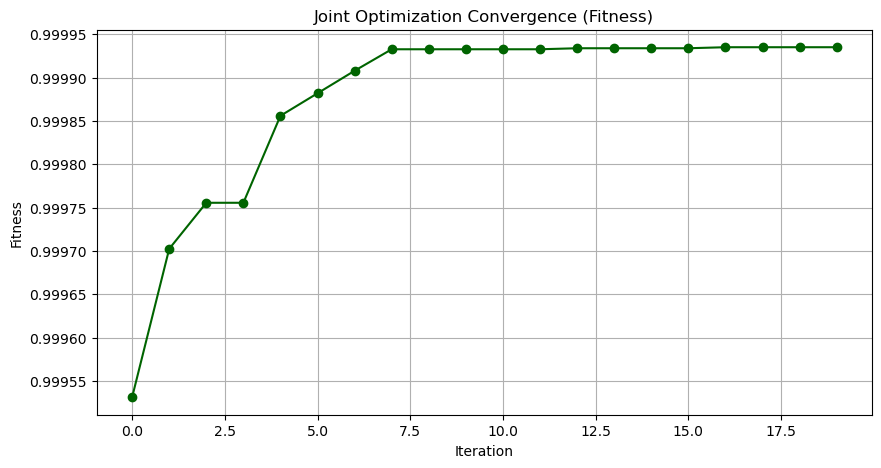

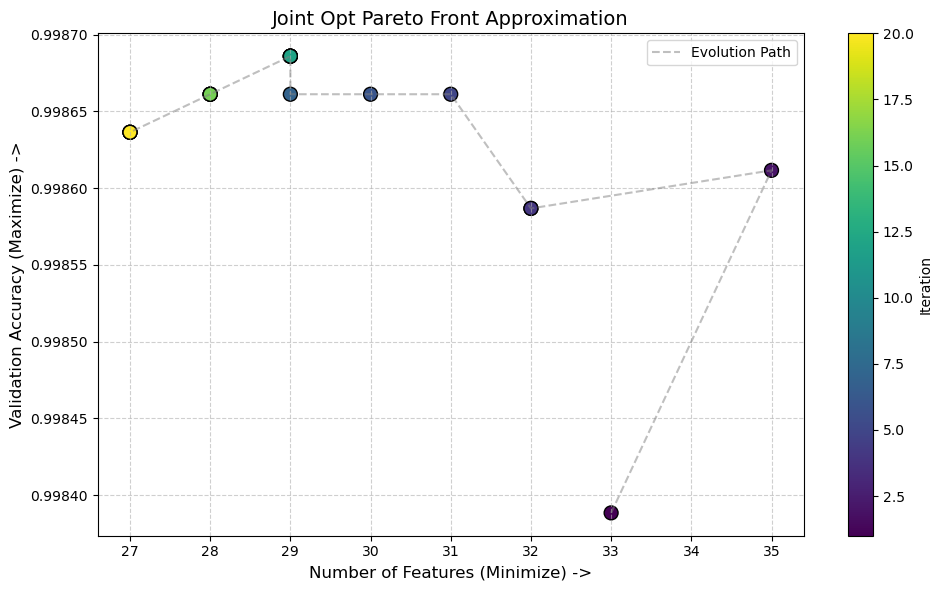

In [11]:
# Run Joint Optimization
# Use available CPU cores
n_jobs = os.cpu_count()
print(f"Using {n_jobs} CPU cores for processing.")

# Alpha=0.002 means 100% accuracy with 10 features is better than 100% accuracy with 50 features.
# But 99% accuracy is still better than 98% accuracy regardless of features.
optimizer = Joint_PSOGA_Optimizer(X_train_scaled, y_train, n_particles=30, n_iterations=20, n_jobs=n_jobs, alpha=0.002)
best_vector, best_fitness, history = optimizer.run()

# Decode Final Solution
final_indices, final_params = optimizer.decode_particle(best_vector)
final_features = [feature_names[i] for i in final_indices]
runtime = optimizer.get_runtime()

print("\n--- Optimization Complete ---")
print(f"Best Fitness Score: {best_fitness:.4f}")
print(f"Optimal Hyperparameters: {final_params}")
print(f"Selected Features ({len(final_features)}/{len(feature_names)}): {final_features}")
print(f"Computational Cost (Runtime): {runtime:.4f} seconds")

# Plot Convergence
plt.figure(figsize=(10, 5))
plt.plot(history['fitness'], marker='o', color='darkgreen')
plt.title('Joint Optimization Convergence (Fitness)')
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.grid(True)
plt.show()

# --- Pareto Front Visualization ---
plt.figure(figsize=(10, 6))
# Evolution Path
plt.plot(history['features'], history['accuracy'], color='gray', linestyle='--', alpha=0.5, label='Evolution Path')
# Points (Iterations)
plt.scatter(history['features'], history['accuracy'], c=history['iteration'], cmap='viridis', s=100, edgecolors='black')

plt.colorbar(label='Iteration')
plt.title('Joint Opt Pareto Front Approximation', fontsize=14)
plt.xlabel('Number of Features (Minimize) ->', fontsize=12)
plt.ylabel('Validation Accuracy (Maximize) ->', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Training Final Joint Optimized Model on Test Set...

Classification Report (Joint Optimized Features & Params):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41901
           1       1.00      1.00      1.00      8515

    accuracy                           1.00     50416
   macro avg       1.00      1.00      1.00     50416
weighted avg       1.00      1.00      1.00     50416

=== Joint Optimization Final Metrics ===
Accuracy: 0.998591716915265
Precision: 0.9985917841957829
Recall: 0.998591716915265
F1-Score: 0.9985917498574189
Detection Rate (TPR): 0.9958896065766295
False Positive Rate (FPR): 0.000859168038948951
Feature Count: 27
Runtime (s): 186.89805674552917
Best Params: {'max_depth': 21, 'min_samples_split': 11, 'criterion': 'entropy'}


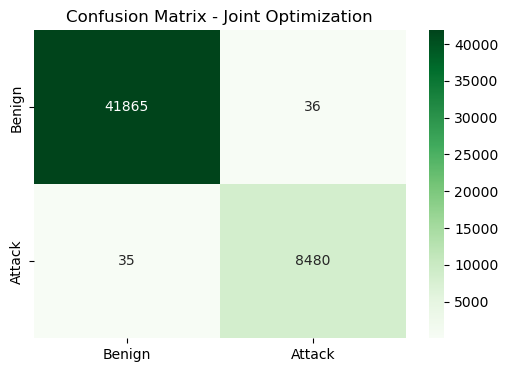

Joint metrics saved to results/joint_metrics.json

=== Model Comparison Results ===
                            Baseline  Joint PSO-GA
Accuracy                    0.998155      0.998592
Precision                   0.998156      0.998592
Recall                      0.998155      0.998592
F1-Score                    0.998155      0.998592
Detection Rate (TPR)        0.994715      0.995890
False Positive Rate (FPR)   0.001146      0.000859
Feature Count              77.000000     27.000000


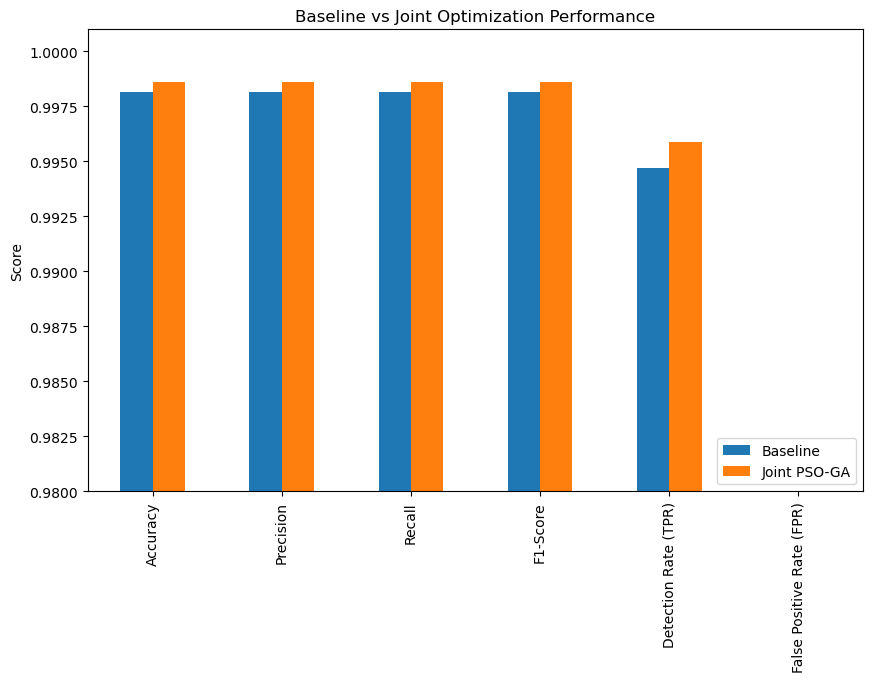

Reduction in Features: 64.94%
Optimized Hyperparameters: {'max_depth': 21, 'min_samples_split': 11, 'criterion': 'entropy'}


In [12]:
# Final Comparison: Joint Optimized vs Baseline

# 1. Train Joint Optimized Model
print("\nTraining Final Joint Optimized Model on Test Set...")

# Use the indices found by the optimizer
X_train_joint = X_train_scaled[:, final_indices]
X_test_joint = X_test_scaled[:, final_indices]

# Use the hyperparameters found by the optimizer
joint_model = DecisionTreeClassifier(
    max_depth=final_params['max_depth'],
    min_samples_split=final_params['min_samples_split'],
    criterion=final_params['criterion'],
    random_state=42
)
joint_model.fit(X_train_joint, y_train)

y_pred_joint = joint_model.predict(X_test_joint)

# Evaluation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_joint).ravel()

joint_acc = accuracy_score(y_test, y_pred_joint)
joint_prec = precision_score(y_test, y_pred_joint, average='weighted')
joint_rec = recall_score(y_test, y_pred_joint, average='weighted')
joint_f1 = f1_score(y_test, y_pred_joint, average='weighted')

detection_rate_joint = tp / (tp + fn)
false_positive_rate_joint = fp / (fp + tn)

print("\nClassification Report (Joint Optimized Features & Params):")
print(classification_report(y_test, y_pred_joint))

# Metrics Dict
joint_final_metrics = {
    'Accuracy': joint_acc,
    'Precision': joint_prec,
    'Recall': joint_rec,
    'F1-Score': joint_f1,
    'Detection Rate (TPR)': detection_rate_joint,
    'False Positive Rate (FPR)': false_positive_rate_joint,
    'Feature Count': len(final_features),
    'Runtime (s)': runtime,
    'Best Params': str(final_params)
}

print("=== Joint Optimization Final Metrics ===")
for k, v in joint_final_metrics.items():
    print(f"{k}: {v}")

conf_matrix_joint = confusion_matrix(y_test, y_pred_joint)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_joint, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - Joint Optimization')
plt.show()

# --- Comparison with Baseline ---
# 1. Load Baseline Mean Metrics from JSON
try:
    with open('results/baseline_metrics.json', 'r') as f:
        baseline_metrics = json.load(f)
except FileNotFoundError:
    print("Warning: baseline_metrics.json not found. Using default placeholder values.")
    baseline_metrics = {
        'Accuracy': 0.9982,
        'Precision': 0.9982,
        'Recall': 0.9982,
        'F1-Score': 0.9982,
        'Detection Rate (TPR)': 0.9947,
        'False Positive Rate (FPR)': 0.001,
        'Feature Count': 77
    }

joint_metrics = {
    'Method': 'Joint Optimization',
    'Accuracy': joint_acc,
    'Precision': joint_prec,
    'Recall': joint_rec,
    'F1-Score': joint_f1,
    'Detection Rate (TPR)': detection_rate_joint,
    'False Positive Rate (FPR)': false_positive_rate_joint,
    'Feature Count': len(final_features),
    'Runtime (s)': runtime
}

# --- SAVE METRICS to JSON ---
joint_metrics_path = 'results/joint_metrics.json'
with open(joint_metrics_path, 'w') as f:
    json.dump(joint_metrics, f, indent=4)
print(f"Joint metrics saved to {joint_metrics_path}")

# Visualization
metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Detection Rate (TPR)', 'False Positive Rate (FPR)', 'Feature Count']
baseline_filtered = {k: baseline_metrics.get(k, 0) for k in metrics_keys}
joint_filtered = {k: joint_metrics.get(k, 0) for k in metrics_keys}

results_df = pd.DataFrame([baseline_filtered, joint_filtered], index=['Baseline', 'Joint PSO-GA'])
print("\n=== Model Comparison Results ===")
print(results_df.T)

results_without_count = results_df.drop('Feature Count', axis=1)
results_without_count.T.plot(kind='bar', figsize=(10, 6))
plt.title('Baseline vs Joint Optimization Performance')
plt.ylabel('Score')
plt.ylim(0.98, 1.001)
plt.legend(loc='lower right')
plt.show()

print(f"Reduction in Features: {((baseline_metrics['Feature Count'] - joint_metrics['Feature Count'])/baseline_metrics['Feature Count'])*100:.2f}%")
print(f"Optimized Hyperparameters: {final_params}")